# 1.데이터 전처리

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import pandas as pd
import folium
from folium import Choropleth

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# CSV 파일 경로 설정
file_path = '/content/drive/MyDrive/2024_하계_알파테스터/전처리/output.csv'

# CSV 파일 읽어오기 (인코딩 설정)
try:
    df = pd.read_csv(file_path, encoding='utf-8')
    print("File read successfully with utf-8 encoding.")
except UnicodeDecodeError:
    print("utf-8 encoding failed, trying euc-kr encoding.")
    try:
        df = pd.read_csv(file_path, encoding='euc-kr')
        print("File read successfully with euc-kr encoding.")
    except UnicodeDecodeError:
        print("euc-kr encoding failed, trying cp949 encoding.")
        try:
            df = pd.read_csv(file_path, encoding='cp949')
            print("File read successfully with cp949 encoding.")
        except UnicodeDecodeError:
            print("cp949 encoding failed. Please check the file encoding.")

# 데이터프레임 확인
df.head()

File read successfully with utf-8 encoding.


,시도,시군구,노인인구수,여성노인인구수,치매환자수,치매환자유병률,중증 환자,경도인지장애 환자수,경도인지장애 환자유병률,독거노인가구비율,기초연금_수급권자수,치매전담형 장기요양기관 수,치매전담형 장기요양기관 정원,치매전담형 장기요양기관 종사자수,치매안심병원 유무,시설 수,정원,종사자 수
0,서울특별시,서울_종로구,27661.5,15238.5,3127.29,11.31,484.73,6419.92,23.21,8.5,14447.0,1,20,7,0,102,458,496
1,서울특별시,서울_중구,24713.5,13792.0,2662.26,10.77,412.65,5671.50,22.95,9.7,14734.0,1,16,4,0,85,528,490
2,서울특별시,서울_용산구,38033.0,21471.5,4249.27,11.17,658.64,8782.64,23.09,7.3,16099.0,0,0,0,0,136,456,337
3,서울특별시,서울_성동구,47964.0,26850.5,4889.99,10.20,757.95,10951.29,22.83,7.0,24162.0,5,85,43,0,228,816,757
4,서울특별시,서울_광진구,54690.5,30211.0,5323.19,9.73,825.09,12342.12,22.57,6.3,28780.0,0,0,0,0,172,1865,925


In [ ]:
top20_max_staff = df.nlargest(20, '치매전담형 장기요양기관 수')

# 결과 출력
print("상위 20개 시도와 구:")
for index, row in top20_max_staff.iterrows():
    print(f"시군구: {row['시군구']}, 치매전담형 장기요양기관 수: {row['치매전담형 장기요양기관 수']}")

상위 20개 시도와 구:
시군구: 인천_서구, 치매전담형 장기요양기관 수: 13
시군구: 충남_당진시, 치매전담형 장기요양기관 수: 13
시군구: 경기_부천시, 치매전담형 장기요양기관 수: 11
시군구: 경기_파주시, 치매전담형 장기요양기관 수: 11
시군구: 인천_남동구, 치매전담형 장기요양기관 수: 10
시군구: 경기_남양주시, 치매전담형 장기요양기관 수: 10
시군구: 경기_안산시, 치매전담형 장기요양기관 수: 9
시군구: 충북_충주시, 치매전담형 장기요양기관 수: 9
시군구: 울산_중구, 치매전담형 장기요양기관 수: 8
시군구: 경기_고양시, 치매전담형 장기요양기관 수: 8
시군구: 충남_부여군, 치매전담형 장기요양기관 수: 8
시군구: 전북_전주시, 치매전담형 장기요양기관 수: 8
시군구: 전북_군산시, 치매전담형 장기요양기관 수: 8
시군구: 대구_달서구, 치매전담형 장기요양기관 수: 7
시군구: 경기_평택시, 치매전담형 장기요양기관 수: 7
시군구: 전남_순천시, 치매전담형 장기요양기관 수: 7
시군구: 경북_경주시, 치매전담형 장기요양기관 수: 7
시군구: 경북_구미시, 치매전담형 장기요양기관 수: 7
시군구: 서울_동작구, 치매전담형 장기요양기관 수: 6
시군구: 대전_동구, 치매전담형 장기요양기관 수: 6


In [ ]:
df['시군구'].unique()

array(['서울_종로구', '서울_중구', '서울_용산구', '서울_성동구', '서울_광진구', '서울_동대문구',
       '서울_중랑구', '서울_성북구', '서울_강북구', '서울_도봉구', '서울_노원구', '서울_은평구',
       '서울_서대문구', '서울_마포구', '서울_양천구', '서울_강서구', '서울_구로구', '서울_금천구',
       '서울_영등포구', '서울_동작구', '서울_관악구', '서울_서초구', '서울_강남구', '서울_송파구',
       '서울_강동구', '부산_중구', '부산_서구', '부산_동구', '부산_영도구', '부산_부산진구', '부산_동래구',
       '부산_남구', '부산_북구', '부산_해운대구', '부산_사하구', '부산_금정구', '부산_강서구',
       '부산_연제구', '부산_수영구', '부산_사상구', '부산_기장군', '대구_중구', '대구_동구', '대구_서구',
       '대구_남구', '대구_북구', '대구_수성구', '대구_달서구', '대구_달성군', '인천_중구', '인천_동구',
       '인천_미추홀구', '인천_연수구', '인천_남동구', '인천_부평구', '인천_계양구', '인천_서구',
       '인천_강화군', '인천_옹진군', '광주_동구', '광주_서구', '광주_남구', '광주_북구', '광주_광산구',
       '대전_동구', '대전_중구', '대전_서구', '대전_유성구', '대전_대덕구', '울산_중구', '울산_남구',
       '울산_동구', '울산_북구', '울산_울주군', '경기_수원시', '경기_성남시', '경기_의정부시',
       '경기_안양시', '경기_부천시', '경기_광명시', '경기_평택시', '경기_동두천시', '경기_안산시',
       '경기_고양시', '경기_과천시', '경기_구리시', '경기_남양주시', '경기_오산시', '경기_시흥시',
       '경기_군포시', '경기_의왕시', '

In [ ]:
columns = [
    '치매전담형 장기요양기관 종사자수',
    '치매전담형 장기요양기관 수',
    '치매전담형 장기요양기관 정원',
    '기초연금_수급권자수',
    '종사자 수'
]

# 각 컬럼에 대해 상위 20개 시도와 구를 추출하고 출력
for column in columns:
    top20 = df.nlargest(20, column)
    print(f"\n상위 20개 시도와 구 - {column}:")
    for index, row in top20.iterrows():
        print(f"시군구: {row['시군구']}, {column}: {row[column]}")


상위 20개 시도와 구 - 치매전담형 장기요양기관 종사자수:
시군구: 경기_부천시, 치매전담형 장기요양기관 종사자수: 86
시군구: 충남_당진시, 치매전담형 장기요양기관 종사자수: 84
시군구: 인천_서구, 치매전담형 장기요양기관 종사자수: 83
시군구: 인천_남동구, 치매전담형 장기요양기관 종사자수: 81
시군구: 전북_전주시, 치매전담형 장기요양기관 종사자수: 66
시군구: 경기_안산시, 치매전담형 장기요양기관 종사자수: 61
시군구: 울산_중구, 치매전담형 장기요양기관 종사자수: 57
시군구: 경기_남양주시, 치매전담형 장기요양기관 종사자수: 56
시군구: 충남_부여군, 치매전담형 장기요양기관 종사자수: 56
시군구: 경기_파주시, 치매전담형 장기요양기관 종사자수: 52
시군구: 충북_충주시, 치매전담형 장기요양기관 종사자수: 44
시군구: 서울_성동구, 치매전담형 장기요양기관 종사자수: 43
시군구: 서울_강남구, 치매전담형 장기요양기관 종사자수: 41
시군구: 경남_진주시, 치매전담형 장기요양기관 종사자수: 41
시군구: 대구_달서구, 치매전담형 장기요양기관 종사자수: 40
시군구: 경기_고양시, 치매전담형 장기요양기관 종사자수: 40
시군구: 전북_군산시, 치매전담형 장기요양기관 종사자수: 39
시군구: 제주_제주시, 치매전담형 장기요양기관 종사자수: 39
시군구: 경북_경주시, 치매전담형 장기요양기관 종사자수: 37
시군구: 전남_무안군, 치매전담형 장기요양기관 종사자수: 36

상위 20개 시도와 구 - 치매전담형 장기요양기관 수:
시군구: 인천_서구, 치매전담형 장기요양기관 수: 13
시군구: 충남_당진시, 치매전담형 장기요양기관 수: 13
시군구: 경기_부천시, 치매전담형 장기요양기관 수: 11
시군구: 경기_파주시, 치매전담형 장기요양기관 수: 11
시군구: 인천_남동구, 치매전담형 장기요양기관 수: 10
시군구: 경기_남양주시, 치매전담형 장기요양기관 수: 10
시군구: 경기_안산시, 치매전담형 장기요양기관 수: 9
시군구: 충북_충주시

In [ ]:
# 결측치 확인
print(df.isnull().sum())

시도                   0
시군구                  0
노인인구수                0
여성노인인구수              0
치매환자수                0
치매환자유병률              0
중증 환자                0
경도인지장애 환자수           0
경도인지장애 환자유병률         0
독거노인가구비율             0
기초연금_수급권자수           1
치매전담형 장기요양기관 수       0
치매전담형 장기요양기관 정원      0
치매전담형 장기요양기관 종사자수    0
치매안심병원 유무            0
시설 수                 0
정원                   0
종사자 수                0
dtype: int64


In [ ]:
# 결측치 처리
df['기초연금_수급권자수'].fillna(df['기초연금_수급권자수'].mean(), inplace=True)

In [ ]:
# 결측치 확인
print(df.isnull().sum())

시도                   0
시군구                  0
노인인구수                0
여성노인인구수              0
치매환자수                0
치매환자유병률              0
중증 환자                0
경도인지장애 환자수           0
경도인지장애 환자유병률         0
독거노인가구비율             0
기초연금_수급권자수           0
치매전담형 장기요양기관 수       0
치매전담형 장기요양기관 정원      0
치매전담형 장기요양기관 종사자수    0
치매안심병원 유무            0
시설 수                 0
정원                   0
종사자 수                0
dtype: int64


In [ ]:
#정규화

# '시도'와 '시군구' 열을 따로 저장
location_columns = ['시도', '시군구']
location_data = df[location_columns]
df_numeric = df.drop(columns=location_columns)

# 정규화
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# 정규화된 데이터와 '시도'와 '시군구' 열을 다시 결합
df_scaled = pd.concat([location_data.reset_index(drop=True), df_numeric_scaled.reset_index(drop=True)], axis=1)

# 결과 확인
print(df_scaled.head())

      시도     시군구     노인인구수   여성노인인구수     치매환자수   치매환자유병률     중증 환자  \
0  서울특별시  서울_종로구 -0.222188 -0.226856 -0.212966  0.192001 -0.212966   
1  서울특별시   서울_중구 -0.241441 -0.243889 -0.242305 -0.173252 -0.242305   
2  서울특별시  서울_용산구 -0.154453 -0.153461 -0.142180  0.097306 -0.142178   
3  서울특별시  서울_성동구 -0.089596 -0.090122 -0.101756 -0.558797 -0.101756   
4  서울특별시  서울_광진구 -0.045666 -0.050552 -0.074425 -0.876702 -0.074427   

   경도인지장애 환자수  경도인지장애 환자유병률  독거노인가구비율  기초연금_수급권자수  치매전담형 장기요양기관 수  \
0   -0.221256      0.134511 -0.751106   -0.708680       -0.448699   
1   -0.242819     -0.210974 -0.546667   -0.690979       -0.448699   
2   -0.153184     -0.024944 -0.955546   -0.606793       -0.836212   
3   -0.090704     -0.370429 -1.006656   -0.109509        1.101353   
4   -0.050633     -0.715913 -1.125912    0.175305       -0.836212   

   치매전담형 장기요양기관 정원  치매전담형 장기요양기관 종사자수  치매안심병원 유무      시설 수        정원     종사자 수  
0        -0.296315          -0.329104   -0.29277 -1.309349 -0.677974 -0.621666  
1 

# 2.pca

In [ ]:
# 병원이 있는 지역 필터링
X_hospital = df_numeric_scaled[df['치매안심병원 유무'] == 1].values
location_data_hospital = location_data[df['치매안심병원 유무'] == 1]

<Axes: >

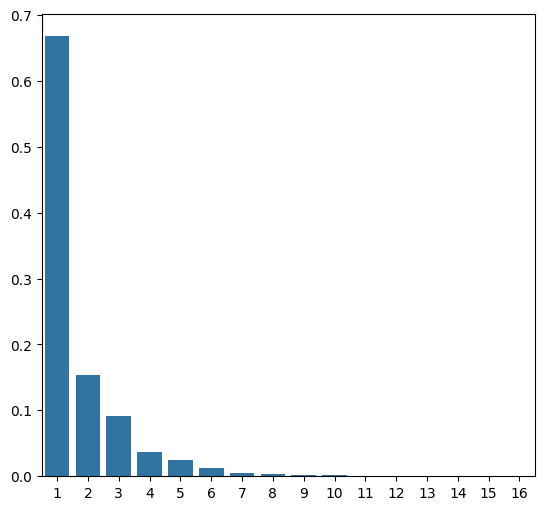

In [ ]:
# PCA 객체 생성 및 적합
pca = PCA()
pca.fit(X_hospital)

# 주성분의 분산 비율 및 누적 분산 비율 계산
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

# 주성분의 분산 비율 히스토그램
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=np.arange(1, len(explained_variance_ratio) + 1), y=explained_variance_ratio)

In [ ]:
# PCA 객체 생성 (주성분 개수 10으로 설정)
n_components = 10
pca = PCA(n_components=n_components)
pca.fit(X_hospital)

# PCA 결과 DataFrame 생성
principal_components_hospital = pca.transform(X_hospital)
pca_df_hospital = pd.DataFrame(data=principal_components_hospital, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df_hospital = pd.concat([location_data_hospital.reset_index(drop=True), pca_df_hospital.reset_index(drop=True)], axis=1)

# PCA 결과 확인
explained_variance_ratio = pca.explained_variance_ratio_
components = pca.components_

# 각 주성분의 원래 특성 기여도 확인
feature_names = df_numeric_scaled.columns
for i, component in enumerate(components):
    print(f"PC{i+1} 주요 특성:")
    component_contributions = zip(feature_names, component)
    sorted_contributions = sorted(component_contributions, key=lambda x: abs(x[1]), reverse=True)
    for feature, contribution in sorted_contributions[:5]:  # 상위 5개 특성만 표시
        print(f"{feature}: {contribution}")
    print("\n")

PC1 주요 특성:
치매전담형 장기요양기관 종사자수: 0.524688237796629
치매전담형 장기요양기관 수: 0.4654399982336365
치매전담형 장기요양기관 정원: 0.4497144330978347
기초연금_수급권자수: 0.314891464666084
종사자 수: 0.22583553433741588


PC2 주요 특성:
경도인지장애 환자유병률: 0.4231619212760083
치매환자유병률: 0.4162677159739649
치매환자수: 0.35186963770345014
중증 환자: 0.3518694408936193
경도인지장애 환자수: 0.3078863931484291


PC3 주요 특성:
치매환자유병률: 0.4626549637384134
경도인지장애 환자유병률: 0.43660158336480587
독거노인가구비율: 0.3003079824846754
중증 환자: -0.27919468251296325
치매환자수: -0.27919396130232027


PC4 주요 특성:
기초연금_수급권자수: -0.6259016846791059
치매전담형 장기요양기관 정원: 0.4968758426274016
시설 수: -0.39606063547782333
종사자 수: -0.27156004450867804
정원: -0.23603042757318982


PC5 주요 특성:
시설 수: -0.6756694746270551
독거노인가구비율: -0.4632725797304752
기초연금_수급권자수: 0.2698799744526955
치매환자유병률: 0.2670982852763956
경도인지장애 환자유병률: 0.2661584912411107


PC6 주요 특성:
독거노인가구비율: 0.47717160644986134
정원: -0.46751630103165154
기초연금_수급권자수: 0.46256024464565804
시설 수: -0.3838164013741498
종사자 수: -0.29514851439147205


PC7 주요 특성:
종사자 수: 0.60973964

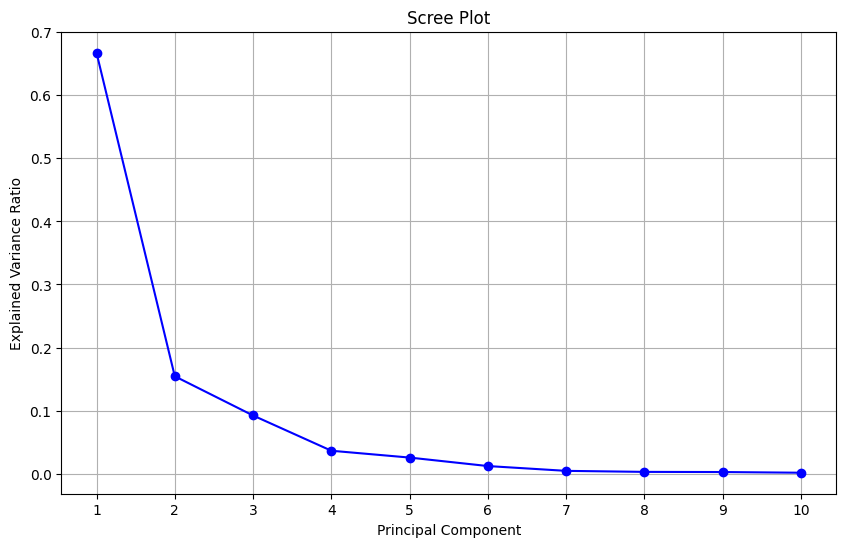

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

In [ ]:
# 병원이 없는 지역 데이터 준비
X_no_hospital = df_numeric_scaled[df['치매안심병원 유무'] == 0].values
location_data_no_hospital = location_data[df['치매안심병원 유무'] == 0]

# 병원이 없는 지역의 주성분 점수 계산
principal_components_no_hospital = pca.transform(X_no_hospital)

# 병원이 없는 지역 DataFrame 생성
pca_df_no_hospital = pd.DataFrame(data=principal_components_no_hospital, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df_no_hospital = pd.concat([location_data_no_hospital.reset_index(drop=True), pca_df_no_hospital.reset_index(drop=True)], axis=1)

# 주성분에 대한 가중치 설정
weights = np.zeros(n_components)
if n_components > 0:
    weights[0] = 0.67  # PC1의 가중치
if n_components > 1:
    weights[1] = 0.19  # PC2의 가중치
if n_components > 2:
    weights[2] = 0.09  # PC3의 가중치
if n_components > 3:
    weights[3] = 0.04  # PC4의 가중치


# 종합 점수 계산
pca_df_no_hospital['Composite_Score'] = pca_df_no_hospital[[f'PC{i+1}' for i in range(n_components)]].dot(weights)

In [ ]:
pca_df_no_hospital.head()

,시도,시군구,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Composite_Score
0,서울특별시,서울_종로구,-2.694585,-0.739155,-0.232976,1.623293,1.041190,0.545821,-0.017995,0.125914,0.148581,-0.201845,-1.901847
1,서울특별시,서울_중구,-2.749868,-1.085562,-0.510108,1.542816,0.814533,0.738835,0.105214,0.223096,0.192430,-0.283108,-2.032866
2,서울특별시,서울_용산구,-3.210545,-0.785015,-0.723552,1.243223,1.087161,0.508766,-0.273670,0.059693,0.221764,-0.150041,-2.315609
3,서울특별시,서울_성동구,0.514343,-0.770726,0.028178,2.038845,0.345060,0.681568,-0.135434,0.028254,-0.039222,-0.363688,0.282262
4,서울특별시,서울_광진구,-2.337041,-1.443456,-1.606190,0.364487,1.022617,0.474698,-0.236667,0.021541,0.033543,-0.418948,-1.970051


In [ ]:
8# 상위 10개 지역 선택
top_locations = pca_df_no_hospital.sort_values(by='Composite_Score', ascending=False).head(30)

# 상위 10개 지역 출력
print("Top 10 Locations by Composite Score:")
print(top_locations[['Composite_Score', '시도', '시군구']])

Top 10 Locations by Composite Score:
     Composite_Score     시도      시군구
68          5.455379    경기도   경기_수원시
79          4.006092    경기도  경기_남양주시
86          3.472931    경기도   경기_파주시
52          3.212045  인천광역시   인천_남동구
132         3.009409   충청남도   충남_당진시
76          2.945488    경기도   경기_고양시
75          2.273629    경기도   경기_안산시
64          1.669163  울산광역시    울산_중구
46          1.535274  대구광역시   대구_달서구
117         1.518479   충청북도   충북_충주시
172         1.500200   경상북도   경북_포항시
134         1.487944   충청남도   충남_부여군
116         1.355377   충청북도   충북_청주시
85          1.341763    경기도   경기_용인시
174         1.291102   경상북도   경북_구미시
151         1.214849   전라남도   전남_목포시
173         1.193012   경상북도   경북_경주시
70          1.066650    경기도  경기_의정부시
153         1.003168   전라남도   전남_순천시
191         0.988234   경상남도   경남_진주시
73          0.972986    경기도   경기_평택시
53          0.681933  인천광역시   인천_부평구
60          0.582923  대전광역시    대전_동구
18          0.551185  서울특별시   서울_동작구
21          0.371149  서울특별시   서울_강남구
1

# 3. 시각화

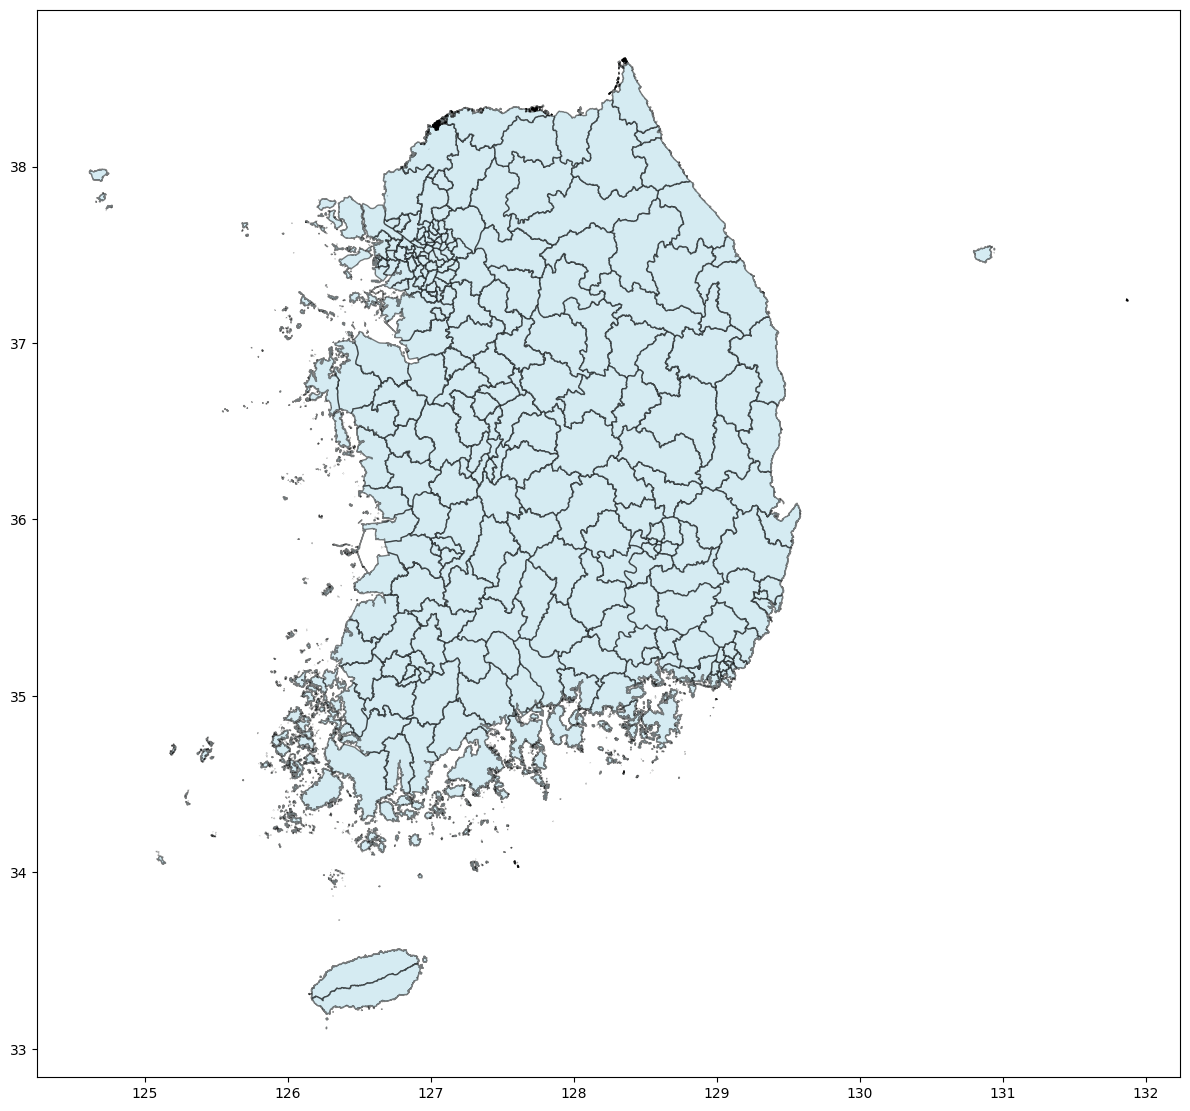

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoJSON 파일 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예를 들어 WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# GeoDataFrame 시각화
gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)

# 레이아웃 자동 조정
plt.tight_layout()

plt.show()

In [ ]:
gdf.head()

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry
0,11110,Jongno-gu,종로구,"POLYGON ((127.01462 37.58210, 127.01395 37.581..."
1,11140,Jung-gu,중구,"POLYGON ((127.02620 37.57245, 127.02575 37.572..."
2,11170,Yongsan-gu,용산구,"POLYGON ((126.97201 37.55619, 126.96984 37.555..."
3,11200,Seongdong-gu,성동구,"POLYGON ((127.07522 37.56049, 127.07480 37.560..."
4,11215,Gwangjin-gu,광진구,"POLYGON ((127.08107 37.57242, 127.08104 37.572..."


In [ ]:
gdf['SIG_KOR_NM'].unique()

array(['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구',
       '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구',
       '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구', '서구', '동구',
       '영도구', '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '연제구',
       '수영구', '사상구', '기장군', '수성구', '달서구', '달성군', '군위군', '미추홀구', '연수구',
       '남동구', '부평구', '계양구', '강화군', '옹진군', '광산구', '유성구', '대덕구', '울주군',
       '세종특별자치시', '수원시 장안구', '수원시 권선구', '수원시 팔달구', '수원시 영통구', '성남시 수정구',
       '성남시 중원구', '성남시 분당구', '의정부시', '안양시 만안구', '안양시 동안구', '부천시', '광명시',
       '평택시', '동두천시', '안산시 상록구', '안산시 단원구', '고양시 덕양구', '고양시 일산동구',
       '고양시 일산서구', '과천시', '구리시', '남양주시', '오산시', '시흥시', '군포시', '의왕시',
       '하남시', '용인시 처인구', '용인시 기흥구', '용인시 수지구', '파주시', '이천시', '안성시', '김포시',
       '화성시', '광주시', '양주시', '포천시', '여주시', '연천군', '가평군', '양평군', '청주시 상당구',
       '청주시 서원구', '청주시 흥덕구', '청주시 청원구', '충주시', '제천시', '보은군', '옥천군', '영동군',
       '증평군', '진천군', '괴산군', '음성군', '단양군', '천안시 동남구', '천안시 서북구', '공주시',
  

In [ ]:
pca_df_no_hospital['시군구'].unique()

array(['서울_종로구', '서울_중구', '서울_용산구', '서울_성동구', '서울_광진구', '서울_동대문구',
       '서울_중랑구', '서울_성북구', '서울_강북구', '서울_도봉구', '서울_노원구', '서울_서대문구',
       '서울_마포구', '서울_양천구', '서울_강서구', '서울_구로구', '서울_금천구', '서울_영등포구',
       '서울_동작구', '서울_관악구', '서울_서초구', '서울_강남구', '서울_송파구', '서울_강동구',
       '부산_중구', '부산_서구', '부산_동구', '부산_영도구', '부산_부산진구', '부산_동래구', '부산_남구',
       '부산_북구', '부산_해운대구', '부산_사하구', '부산_금정구', '부산_강서구', '부산_연제구',
       '부산_수영구', '부산_사상구', '부산_기장군', '대구_중구', '대구_동구', '대구_서구', '대구_남구',
       '대구_북구', '대구_수성구', '대구_달서구', '대구_달성군', '인천_중구', '인천_동구', '인천_미추홀구',
       '인천_연수구', '인천_남동구', '인천_부평구', '인천_강화군', '인천_옹진군', '광주_동구', '광주_서구',
       '광주_남구', '광주_북구', '대전_동구', '대전_중구', '대전_서구', '대전_대덕구', '울산_중구',
       '울산_남구', '울산_동구', '울산_북구', '경기_수원시', '경기_성남시', '경기_의정부시', '경기_안양시',
       '경기_광명시', '경기_평택시', '경기_동두천시', '경기_안산시', '경기_고양시', '경기_과천시',
       '경기_구리시', '경기_남양주시', '경기_오산시', '경기_시흥시', '경기_군포시', '경기_의왕시',
       '경기_하남시', '경기_용인시', '경기_파주시', '경기_이천시', '경기_안성시', '경기_김포시',
       '경기_화성시', 

In [ ]:
pca_df_no_hospital.head()

,시도,시군구,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Composite_Score
0,서울특별시,서울_종로구,-2.694585,-0.739155,-0.232976,1.623293,1.041190,0.545821,-0.017995,0.125914,0.148581,-0.201845,-1.901847
1,서울특별시,서울_중구,-2.749868,-1.085562,-0.510108,1.542816,0.814533,0.738835,0.105214,0.223096,0.192430,-0.283108,-2.032866
2,서울특별시,서울_용산구,-3.210545,-0.785015,-0.723552,1.243223,1.087161,0.508766,-0.273670,0.059693,0.221764,-0.150041,-2.315609
3,서울특별시,서울_성동구,0.514343,-0.770726,0.028178,2.038845,0.345060,0.681568,-0.135434,0.028254,-0.039222,-0.363688,0.282262
4,서울특별시,서울_광진구,-2.337041,-1.443456,-1.606190,0.364487,1.022617,0.474698,-0.236667,0.021541,0.033543,-0.418948,-1.970051


In [ ]:
# 상위 5개 Composite_Score 필터링
top_5_df = pca_df_no_hospital.nlargest(5, 'Composite_Score')

# 상위 5개 출력
print(top_5_df[['시군구', 'Composite_Score']])

         시군구  Composite_Score
68    경기_수원시         5.455379
79   경기_남양주시         4.006092
86    경기_파주시         3.472931
52    인천_남동구         3.212045
132   충남_당진시         3.009409


In [ ]:
gdf.head()

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry
0,11110,Jongno-gu,종로구,"POLYGON ((127.01462 37.58210, 127.01395 37.581..."
1,11140,Jung-gu,중구,"POLYGON ((127.02620 37.57245, 127.02575 37.572..."
2,11170,Yongsan-gu,용산구,"POLYGON ((126.97201 37.55619, 126.96984 37.555..."
3,11200,Seongdong-gu,성동구,"POLYGON ((127.07522 37.56049, 127.07480 37.560..."
4,11215,Gwangjin-gu,광진구,"POLYGON ((127.08107 37.57242, 127.08104 37.572..."


In [ ]:
pca_df_no_hospital['시군구'] = pca_df_no_hospital['시군구'].apply(lambda x: x.split('_')[1] if '_' in x else x)

In [ ]:
# # 병합 수행
# merged_gdf = gdf.merge(pca_df_no_hospital[['시군구', 'Composite_Score']],
#                        left_on='SIG_KOR_NM', right_on='시군구',
#                        how='left')

# # 병합 후 'Composite_Score'를 gdf에 추가
# gdf['Composite_Score'] = merged_gdf['Composite_Score']

In [ ]:
gdf.head()

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry
0,11110,Jongno-gu,종로구,"POLYGON ((127.01462 37.58210, 127.01395 37.581..."
1,11140,Jung-gu,중구,"POLYGON ((127.02620 37.57245, 127.02575 37.572..."
2,11170,Yongsan-gu,용산구,"POLYGON ((126.97201 37.55619, 126.96984 37.555..."
3,11200,Seongdong-gu,성동구,"POLYGON ((127.07522 37.56049, 127.07480 37.560..."
4,11215,Gwangjin-gu,광진구,"POLYGON ((127.08107 37.57242, 127.08104 37.572..."


In [ ]:
# 병합 전에 키 값 확인
print("Unique values in pca_df_no_hospital['시군구']:")
print(pca_df_no_hospital['시군구'].unique())

print("\nUnique values in gdf['SIG_KOR_NM']:")
print(gdf['SIG_KOR_NM'].unique())

Unique values in pca_df_no_hospital['시군구']:
['종로구' '중구' '용산구' '성동구' '광진구' '동대문구' '중랑구' '성북구' '강북구' '도봉구' '노원구' '서대문구'
 '마포구' '양천구' '강서구' '구로구' '금천구' '영등포구' '동작구' '관악구' '서초구' '강남구' '송파구' '강동구'
 '서구' '동구' '영도구' '부산진구' '동래구' '남구' '북구' '해운대구' '사하구' '금정구' '연제구' '수영구'
 '사상구' '기장군' '수성구' '달서구' '달성군' '미추홀구' '연수구' '남동구' '부평구' '강화군' '옹진군' '대덕구'
 '수원시' '성남시' '의정부시' '안양시' '광명시' '평택시' '동두천시' '안산시' '고양시' '과천시' '구리시'
 '남양주시' '오산시' '시흥시' '군포시' '의왕시' '하남시' '용인시' '파주시' '이천시' '안성시' '김포시' '화성시'
 '광주시' '양주시' '포천시' '여주시' '연천군' '가평군' '양평군' '춘천시' '원주시' '강릉시' '동해시' '태백시'
 '속초시' '삼척시' '홍천군' '횡성군' '영월군' '평창군' '정선군' '철원군' '화천군' '양구군' '인제군' '고성군'
 '양양군' '청주시' '충주시' '보은군' '옥천군' '영동군' '진천군' '괴산군' '음성군' '단양군' '증평군' '천안시'
 '공주시' '보령시' '아산시' '논산시' '계룡시' '당진시' '금산군' '부여군' '서천군' '청양군' '예산군' '태안군'
 '익산시' '정읍시' '남원시' '김제시' '완주군' '진안군' '무주군' '장수군' '임실군' '순창군' '고창군' '부안군'
 '목포시' '여수시' '순천시' '나주시' '광양시' '담양군' '곡성군' '구례군' '고흥군' '보성군' '장흥군' '강진군'
 '해남군' '영암군' '무안군' '함평군' '영광군' '장성군' '완도군' '진도군' '신안군' '포항시' '경주시' '구미시'
 '영주시' '영

Composite_Score 상위 5개 시군구:
    SIG_KOR_NM  Composite_Score
97        남양주시         4.006092
106        파주시         3.472931
54         남동구         3.212045
140        당진시         3.009409
47         달서구         1.535274


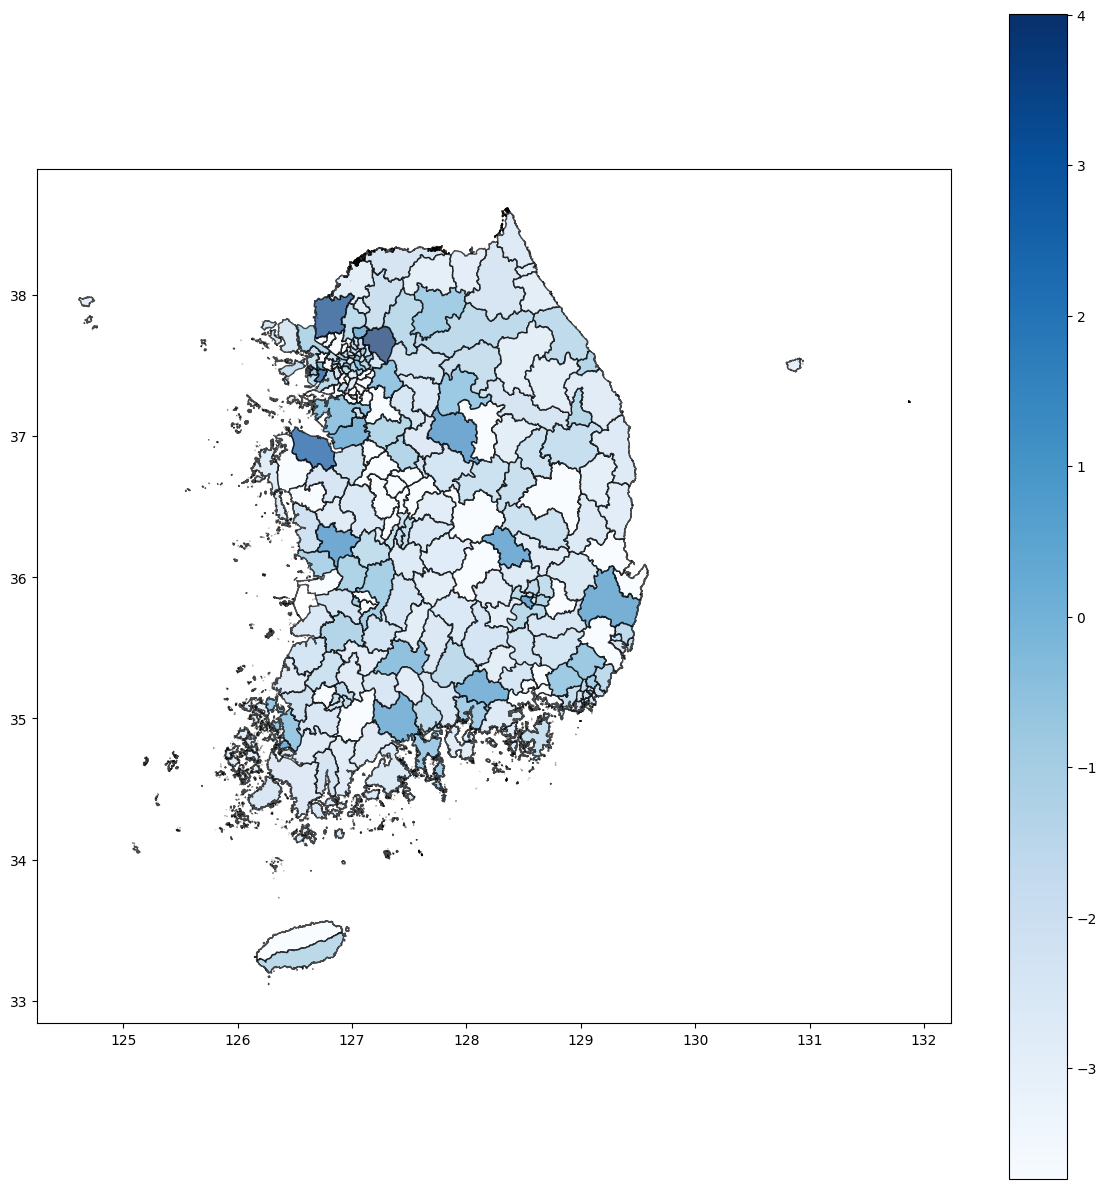

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoJSON 파일 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예를 들어 WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    # 예: '수원시_장안구', '수원시_권선구' 등을 '수원시'로 통합
    return region_name.split('_')[0]

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# pca_df_no_hospital에서 지역별 Composite_Score 평균 계산
region_scores = pca_df_no_hospital.groupby('Region')['Composite_Score'].mean().reset_index()

# 지역별 점수를 gdf에 추가
merged_gdf = gdf.merge(region_scores, left_on='Region', right_on='Region', how='left')

# 병합 후 'Composite_Score'를 gdf에 추가
gdf['Composite_Score'] = merged_gdf['Composite_Score']

# Composite_Score의 NaN 값을 가장 작은 값보다 작은 값으로 대체
min_score = region_scores['Composite_Score'].min()
gdf['Composite_Score'] = gdf['Composite_Score'].fillna(min_score - 1)

# 상위 5개 Composite_Score가 높은 시군구 추출
top_5 = gdf.nlargest(5, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("Composite_Score 상위 5개 시군구:")
print(top_5)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# Composite_Score 값을 기준으로 색상 맵핑 (파란색 계열)
gdf.plot(ax=ax, column='Composite_Score', cmap='Blues', legend=True, edgecolor='black', alpha=0.7)

# 레이아웃 자동 조정
plt.tight_layout()

# 시각화 출력
plt.show()


Composite_Score 상위 5개 시군구:
    SIG_KOR_NM  Composite_Score
198       남양주시         4.006092
207        파주시         3.472931
109        남동구         3.212045
241        당진시         3.009409
6           중구         1.669163


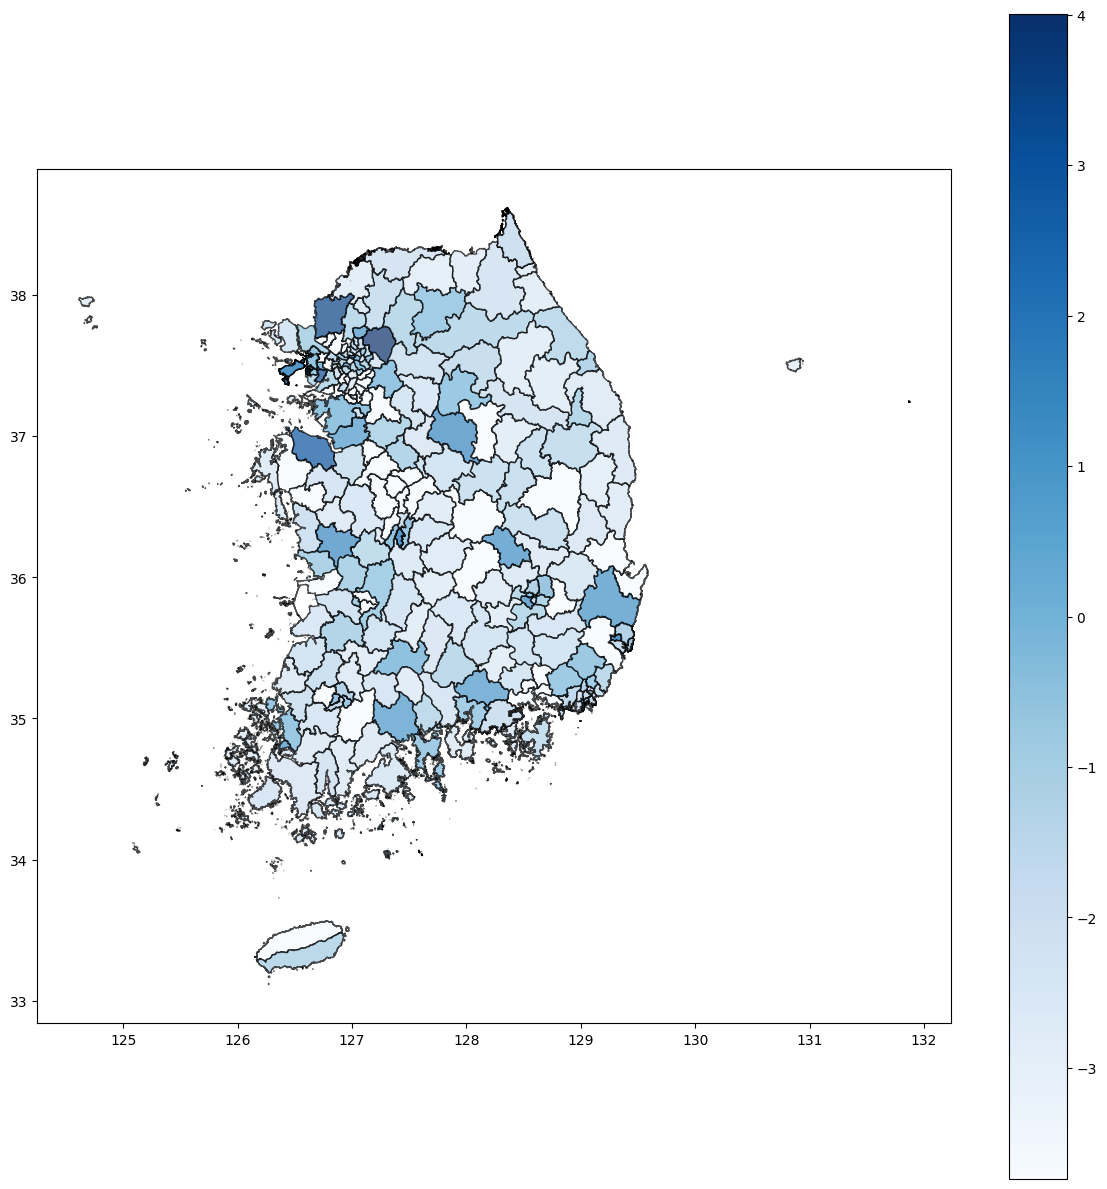

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoJSON 파일 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예: WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    # 예: '수원시_장안구', '수원시_권선구' 등을 '수원시'로 통합
    return region_name.split('_')[0]

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# Composite_Score의 NaN 값을 가장 작은 값보다 작은 값으로 대체
min_score = region_scores['Composite_Score'].min()
gdf['Composite_Score'] = gdf['Composite_Score'].fillna(min_score - 1)

# 상위 5개 Composite_Score가 높은 시군구 추출
top_5 = gdf.nlargest(5, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("Composite_Score 상위 5개 시군구:")
print(top_5)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# Composite_Score 값을 기준으로 색상 맵핑 (파란색 계열)
gdf.plot(ax=ax, column='Composite_Score', cmap='Blues', legend=True, edgecolor='black', alpha=0.7)

# 레이아웃 자동 조정
plt.tight_layout()

# 시각화 출력
plt.show()


Composite_Score 상위 5개 시군구:
    SIG_KOR_NM  Composite_Score
198       남양주시         4.006092
207        파주시         3.472931
109        남동구         3.212045
241        당진시         3.009409
6           중구         1.669163


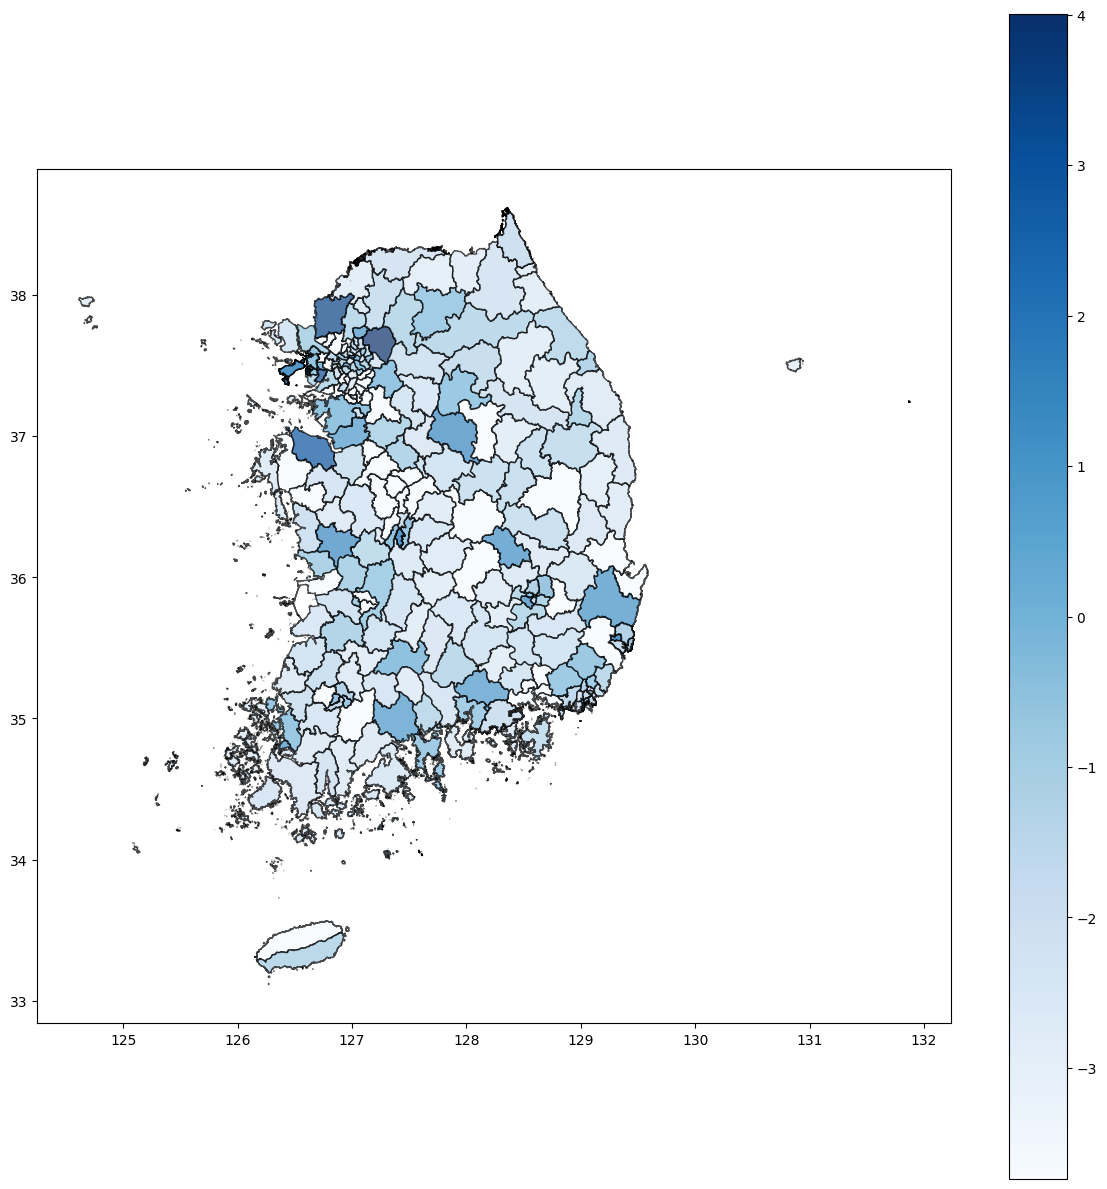

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoJSON 파일 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예: WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    # 예: '수원시_장안구', '수원시_권선구' 등을 '수원시'로 통합
    return region_name.split('_')[0]

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# Composite_Score의 NaN 값을 가장 작은 값보다 작은 값으로 대체
min_score = region_scores['Composite_Score'].min()
gdf['Composite_Score'] = gdf['Composite_Score'].fillna(min_score - 1)

# 상위 5개 Composite_Score가 높은 시군구 추출
top_5 = gdf.nlargest(5, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("Composite_Score 상위 5개 시군구:")
print(top_5)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# Composite_Score 값을 기준으로 색상 맵핑 (파란색 계열)
gdf.plot(ax=ax, column='Composite_Score', cmap='Blues', legend=True, edgecolor='black', alpha=0.7)

# 레이아웃 자동 조정
plt.tight_layout()

# 시각화 출력
plt.show()


In [ ]:
# 수원시의 Composite_Score 추출
suwon_score = region_scores[region_scores['Region'] == '수원시']

print("\n수원시의 Composite_Score:")
print(suwon_score)


수원시의 Composite_Score:
   Region  Composite_Score
68    수원시         5.455379


병합 후 gdf의 일부 데이터:
  SIG_KOR_NM Region  Composite_Score
0        종로구    종로구        -1.901847
1         중구     중구        -2.032866
2         중구     중구        -2.607892
3         중구     중구        -2.480360
4         중구     중구        -0.471352
5         중구     중구        -1.563528
6         중구     중구         1.669163
7        용산구    용산구        -2.315609
8        성동구    성동구         0.282262
9        광진구    광진구        -1.970051

수원시의 Composite_Score:
   Region  Composite_Score
68    수원시         5.455379

Composite_Score 상위 5개 시군구:
    SIG_KOR_NM  Composite_Score
198       남양주시         4.006092
207        파주시         3.472931
109        남동구         3.212045
241        당진시         3.009409
6           중구         1.669163


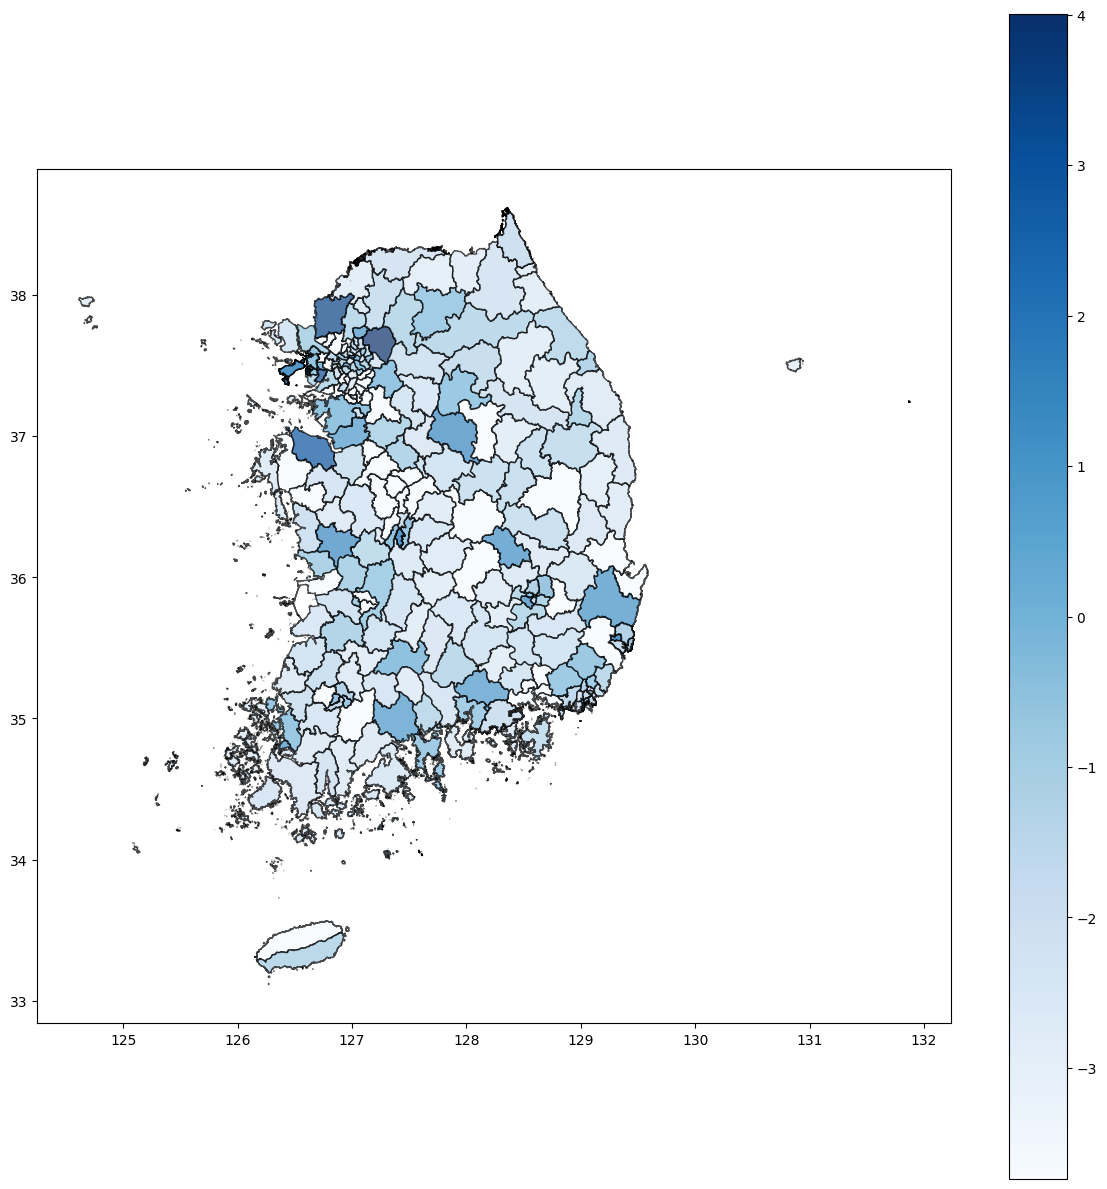

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoJSON 파일 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예: WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    # 예: '수원시_장안구', '수원시_권선구' 등을 '수원시'로 통합
    return region_name.split('_')[0]

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# 지역별 Composite_Score가 제대로 병합되었는지 확인
print("병합 후 gdf의 일부 데이터:")
print(gdf[['SIG_KOR_NM', 'Region', 'Composite_Score']].head(10))

# Composite_Score의 NaN 값을 가장 작은 값보다 작은 값으로 대체
min_score = region_scores['Composite_Score'].min()
gdf['Composite_Score'] = gdf['Composite_Score'].fillna(min_score - 1)

# 수원시의 Composite_Score 추출
suwon_score = region_scores[region_scores['Region'] == '수원시']
print("\n수원시의 Composite_Score:")
print(suwon_score)

# 상위 5개 Composite_Score가 높은 시군구 추출
top_5 = gdf.nlargest(5, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("\nComposite_Score 상위 5개 시군구:")
print(top_5)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# Composite_Score 값을 기준으로 색상 맵핑 (파란색 계열)
gdf.plot(ax=ax, column='Composite_Score', cmap='Blues', legend=True, edgecolor='black', alpha=0.7)

# 레이아웃 자동 조정
plt.tight_layout()

# 시각화 출력
plt.show()


In [ ]:
# pca_df_no_hospital의 Region 값을 정리
pca_df_no_hospital['Region'] = pca_df_no_hospital['Region'].str.strip()

# gdf의 Region 값을 정리
gdf['Region'] = gdf['Region'].str.strip()

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# 병합 결과를 검토
print("병합 후 gdf의 일부 데이터:")
print(gdf[['SIG_KOR_NM', 'Region', 'Composite_Score']].head(10))

# 상위 5개 Composite_Score가 높은 시군구 추출
top_5 = gdf.nlargest(5, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("\nComposite_Score 상위 5개 시군구:")
print(top_5)


병합 후 gdf의 일부 데이터:
  SIG_KOR_NM Region  Composite_Score
0        종로구    종로구        -1.901847
1         중구     중구        -2.032866
2         중구     중구        -2.607892
3         중구     중구        -2.480360
4         중구     중구        -0.471352
5         중구     중구        -1.563528
6         중구     중구         1.669163
7         중구     중구        -2.032866
8         중구     중구        -2.607892
9         중구     중구        -2.480360

Composite_Score 상위 5개 시군구:
     SIG_KOR_NM  Composite_Score
3510       남양주시         4.006092
3519        파주시         3.472931
1951        남동구         3.212045
3553        당진시         3.009409
6            중구         1.669163


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 예제 데이터 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예: WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    return region_name.split('_')[0]

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# 데이터의 고유 값 확인
print("gdf의 Region 고유 값:")
print(gdf['Region'].unique())

print("pca_df_no_hospital의 Region 고유 값:")
print(pca_df_no_hospital['Region'].unique())

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# 병합된 gdf 데이터의 일부 출력
print("병합 후 gdf의 데이터 샘플:")
print(gdf[['SIG_KOR_NM', 'Region', 'Composite_Score']].head(10))

# 수원시의 Composite_Score 확인
suwon_score = gdf[gdf['Region'] == '수원시'][['SIG_KOR_NM', 'Region', 'Composite_Score']]
print("\n수원시의 Composite_Score:")
print(suwon_score)


gdf의 Region 고유 값:
['종로구' '중구' '용산구' '성동구' '광진구' '동대문구' '중랑구' '성북구' '강북구' '도봉구' '노원구' '은평구'
 '서대문구' '마포구' '양천구' '강서구' '구로구' '금천구' '영등포구' '동작구' '관악구' '서초구' '강남구' '송파구'
 '강동구' '서구' '동구' '영도구' '부산진구' '동래구' '남구' '북구' '해운대구' '사하구' '금정구' '연제구'
 '수영구' '사상구' '기장군' '수성구' '달서구' '달성군' '군위군' '미추홀구' '연수구' '남동구' '부평구' '계양구'
 '강화군' '옹진군' '광산구' '유성구' '대덕구' '울주군' '세종특별자치시' '수원시 장안구' '수원시 권선구'
 '수원시 팔달구' '수원시 영통구' '성남시 수정구' '성남시 중원구' '성남시 분당구' '의정부시' '안양시 만안구'
 '안양시 동안구' '부천시' '광명시' '평택시' '동두천시' '안산시 상록구' '안산시 단원구' '고양시 덕양구'
 '고양시 일산동구' '고양시 일산서구' '과천시' '구리시' '남양주시' '오산시' '시흥시' '군포시' '의왕시' '하남시'
 '용인시 처인구' '용인시 기흥구' '용인시 수지구' '파주시' '이천시' '안성시' '김포시' '화성시' '광주시' '양주시'
 '포천시' '여주시' '연천군' '가평군' '양평군' '청주시 상당구' '청주시 서원구' '청주시 흥덕구' '청주시 청원구'
 '충주시' '제천시' '보은군' '옥천군' '영동군' '증평군' '진천군' '괴산군' '음성군' '단양군' '천안시 동남구'
 '천안시 서북구' '공주시' '보령시' '아산시' '서산시' '논산시' '계룡시' '당진시' '금산군' '부여군' '서천군'
 '청양군' '홍성군' '예산군' '태안군' '전주시 완산구' '전주시 덕진구' '군산시' '익산시' '정읍시' '남원시' '김제시'
 '완주군' '진안군' '무주군' '장수군' '임실군' '순창군' '고창군' '부안군' '목포시' 

병합 후 gdf의 데이터 샘플:
  SIG_KOR_NM Region  Composite_Score
0        종로구    종로구        -1.901847
1         중구     중구        -2.032866
2         중구     중구        -2.607892
3         중구     중구        -2.480360
4         중구     중구        -0.471352
5         중구     중구        -1.563528
6         중구     중구         1.669163
7        용산구    용산구        -2.315609
8        성동구    성동구         0.282262
9        광진구    광진구        -1.970051

Composite_Score 상위 15개 시군구:
    SIG_KOR_NM  Composite_Score
177    수원시 장안구         5.455379
178    수원시 권선구         5.455379
179    수원시 팔달구         5.455379
180    수원시 영통구         5.455379
198       남양주시         4.006092
207        파주시         3.472931
109        남동구         3.212045
241        당진시         3.009409
6           중구         1.669163
36          중구         1.669163
72          중구         1.669163
100         중구         1.669163
148         중구         1.669163
160         중구         1.669163
92         달서구         1.535274

수원시의 Composite_Score:
    SIG_KOR

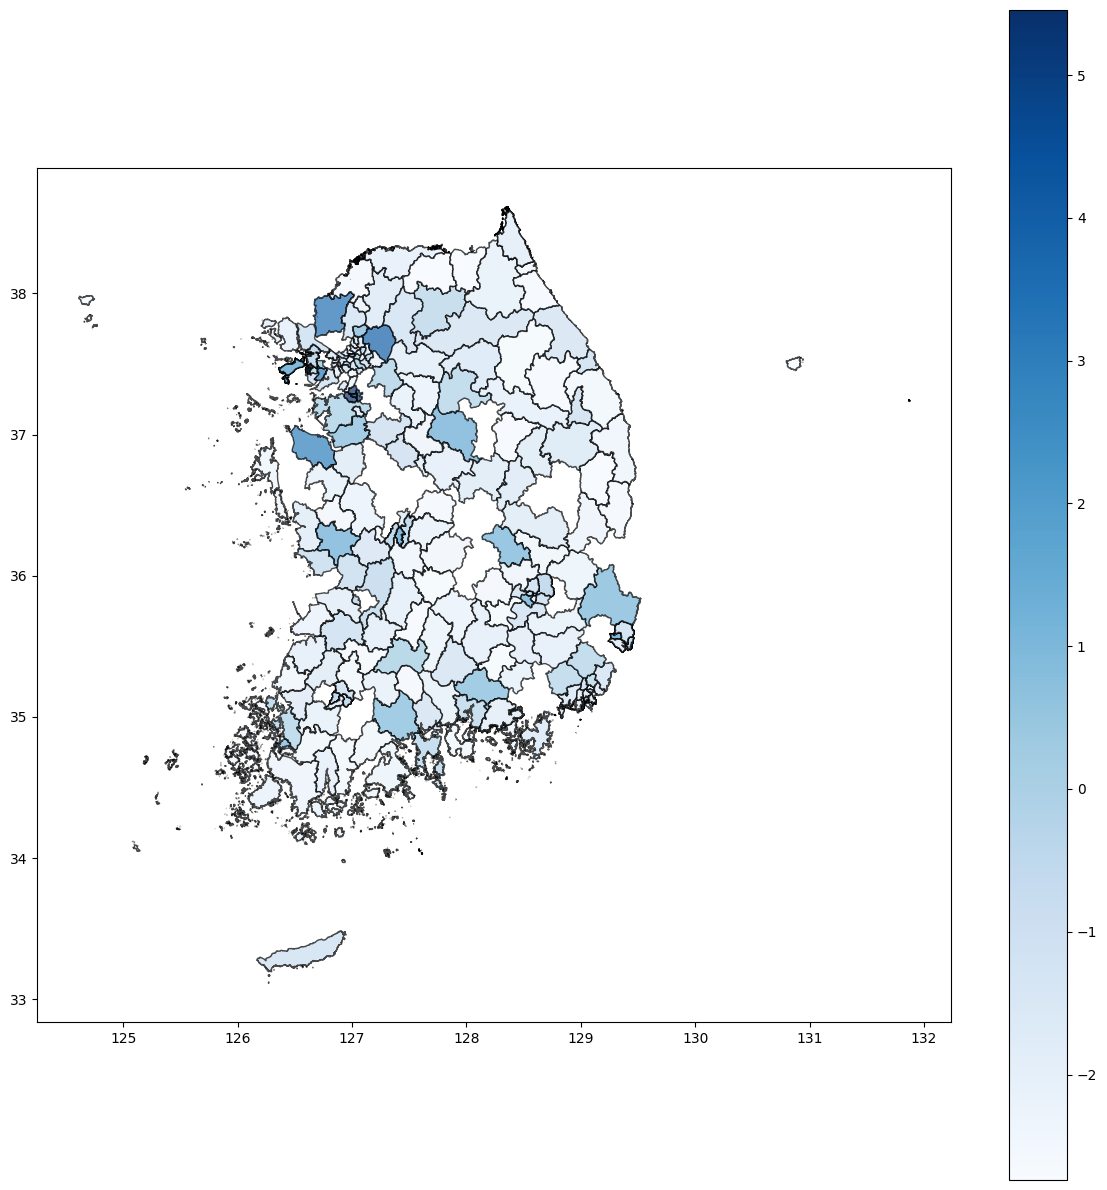

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 예제 데이터 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예: WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    # '수원시'로 시작하는 경우 모두 '수원시'로 통합
    if '수원시' in region_name:
        return '수원시'
    return region_name.split('_')[0]

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# '수원시'의 Composite_Score를 추출
suwon_score_value = region_scores[region_scores['Region'] == '수원시']['Composite_Score'].values

# '수원시'의 점수가 존재하면 해당 점수를 모든 '수원시' 하위 구역에 적용
if len(suwon_score_value) > 0:
    suwon_score_value = suwon_score_value[0]
else:
    suwon_score_value = float('nan')

# 모든 '수원시' 하위 구역의 'Composite_Score'를 수원시 점수로 설정
gdf.loc[gdf['Region'] == '수원시', 'Composite_Score'] = suwon_score_value

# 병합된 gdf 데이터의 일부 출력
print("병합 후 gdf의 데이터 샘플:")
print(gdf[['SIG_KOR_NM', 'Region', 'Composite_Score']].head(10))

# 상위 5개 Composite_Score가 높은 시군구 추출
top_15 = gdf.nlargest(15, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("\nComposite_Score 상위 15개 시군구:")
print(top_15)

# 수원시의 Composite_Score 확인
suwon_score = gdf[gdf['Region'] == '수원시'][['SIG_KOR_NM', 'Region', 'Composite_Score']]
print("\n수원시의 Composite_Score:")
print(suwon_score)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# Composite_Score 값을 기준으로 색상 맵핑 (파란색 계열)
gdf.plot(ax=ax, column='Composite_Score', cmap='Blues', legend=True, edgecolor='black', alpha=0.7)

# 레이아웃 자동 조정
plt.tight_layout()

# 시각화 출력
plt.show()